# EDA — Gravity Spy O3

Checklist:
1. Load one glitch: show its 0.5 / 1 / 2 / 4 s spectrograms side by side.
2. Class distribution bar chart. How bad is the imbalance?
3. Confirm the provided split sizes (train/val/test) and that no
   `gravityspy_id` leaks across splits.
4. Inspect the metadata CSV: peak frequency, SNR, bandwidth ranges per class.
   Do low-frequency classes (scattered light) separate visibly?

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import h5py

train_metadata_path = "../data/metadata/trainingset_metadata.csv"
train_data_path = "../data/training/trainingset.h5"

In [17]:
# let's look at a glitch spectrogram
train_data = h5py.File(train_data_path, "r")
print(list(train_data.keys()))

['1080Lines', '1400Ripples', 'Air_Compressor', 'Blip', 'Chirp', 'Extremely_Loud', 'Helix', 'Koi_Fish', 'Light_Modulation', 'Low_Frequency_Burst', 'Low_Frequency_Lines', 'No_Glitch', 'None_of_the_Above', 'Paired_Doves', 'Power_Line', 'Repeating_Blips', 'Scattered_Light', 'Scratchy', 'Tomte', 'Violin_Mode', 'Wandering_Line', 'Whistle']


In [48]:
# column indexing yields a Dataset object
d = train_data['Blip']['train']['017BiNepgE']
print(d.keys())

<KeysViewHDF5 ['0.5.png', '1.0.png', '2.0.png', '4.0.png']>


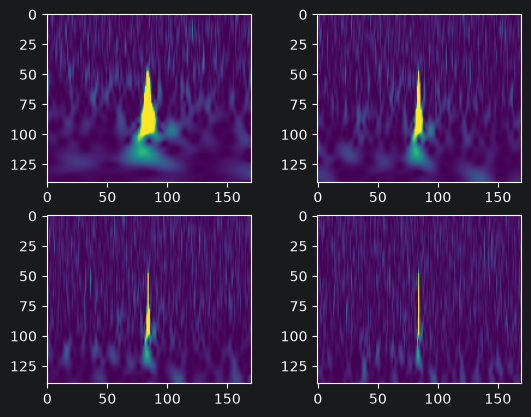

In [50]:
fig, axs = plt.subplots(2, 2)
images = []
for duration in [0.5, 1.0, 2.0, 4.0]:
    dset = train_data['Blip']['train']['017BiNepgE'][f'{duration}.png']
    image = dset[:] # into numpy array
    image = image.squeeze() # (140, 170)
    images.append(image)

axs[0, 0].imshow(images[0], cmap='viridis')
axs[0, 1].imshow(images[1], cmap='viridis')
axs[1, 0].imshow(images[2], cmap='viridis')
axs[1, 1].imshow(images[3], cmap='viridis')

plt.show()